In [1]:
import random, os, pytz, json
from tqdm import tqdm, trange
from datetime import datetime
timezone = pytz.timezone('America/New_York') 
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
"""
Grammar:
depth < max_depth, max_length >= 2 
X -> \epsilon P = 0.3
X -> (X) P = 0.4
X -> X X P = 0.3

depth < max_depth, 0 < max_length < 2
X -> \epsilon P = 0.3
X -> (X) P = 0.7

depth < max_depth, max_length = 0
X -> \epsilon P = 1.0

depth = max_depth, max_length >= 2 
X -> \epsilon P = 0.3
X -> X X P = 0.7

depth = max_depth, max_length < 2 
X -> \epsilon P = 1.0
"""


In [67]:
def generate(max_depth, depth, max_length, transition):
    if depth < max_depth:
        p = random.random()
        if max_length >= 2:
            if p < transition[0]:
                return ''
            elif p < transition[0] + transition[1]:
                return '(' + generate(max_depth, depth + 1, max_length-2, transition) + ')'
            else:
                return generate(max_depth, depth, max_length//2, transition) + generate(max_depth, depth, max_length//2, transition)
        elif 0 < max_length < 2:
            if p < transition[0]:
                return ''
            else:
                return '(' + generate(max_depth, depth + 1, max_length-2, transition) + ')'
        else:
            return ''
    elif depth == max_depth:
        p = random.random()
        if max_length >= 2:
            if p < transition[0]:
                return ''
            else:
                return generate(max_depth, depth, max_length//2, transition) + generate(max_depth, depth, max_length//2, transition)
        else:
            return ''

In [80]:
def generate_invalid(max_depth, depth, max_length, transition, weights):
    strategy = random.random()
    if strategy < weights[0]: #insert
        s = "e"*max_length
        #while len(s) >= max_length:
        while len(s) >= max_length or len(s) < 2:
            s = generate(max_depth, depth, max_length, transition)
        idx = random.randint(0, len(s)-1)
        if random.random() < 0.5:
            s = s[:idx] + '(' + s[idx:]
        else:
            s = s[:idx] + ')' + s[idx:]
        return s, "insert"
    elif strategy < weights[0] + weights[1]: # remove
        s = ''
        while len(s) < 2:
            s = generate(max_depth, depth, max_length, transition)
        #s = generate(max_depth, depth, max_length, transition)
        idx = random.randint(0, len(s)-1)
        return s[:idx] + s[idx+1:], "remove"
    elif strategy < weights[0] + weights[1] + weights[2]: # swap
        s = ''
        while len(s) < 2:
            s = generate(max_depth, depth, max_length, transition)
        #s = generate(max_depth, depth, max_length, transition)
        idx = random.randint(0, len(s)-1)
        if s[idx] == '(':
            s = s[:idx] + ')' + s[idx+1:]
        else:
            s = s[:idx] + '(' + s[idx+1:]
        return s, "swap"
    else: # (harder) mess up
        s1, s2 = "e"*max_length, "e"*max_length
        #while len(s1) + len(s2) + 2 > max_length:
        while len(s1) + len(s2) + 2 > max_length or len(s1) < 2 or len(s2) < 2:
            s1 = generate(max_depth, depth, max_length, transition)
            s2 = generate(max_depth, depth, max_length, transition)
        idx = random.randint(0, len(s2)-1)
        return s1 + ')' + s2[:idx] + '(' + s2[idx:], "messup"

In [69]:
def double_check(s):
    """
    If it's valid, return the maximum nesting depth.
    If it's not valid, return -1.
    """
    max_depth = 0
    current_depth = 0
    
    for ch in s:
        if ch == '(':
            current_depth += 1
            max_depth = max(max_depth, current_depth)
        elif ch == ')':
            current_depth -= 1
            if current_depth < 0:
                return -1
    if current_depth != 0:
        return -1
    return max_depth

In [70]:
def make_barplot(data, xlabel, ylabel):
    fig= plt.figure(figsize=(6, 3))
    ax = fig.add_subplot(111)
    ax.bar(data.keys(), data.values(), color='lightblue')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines[['right', 'top']].set_visible(False)
    plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:00<00:00, 45126.25it/s]


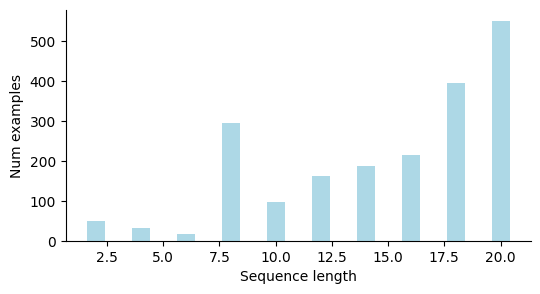

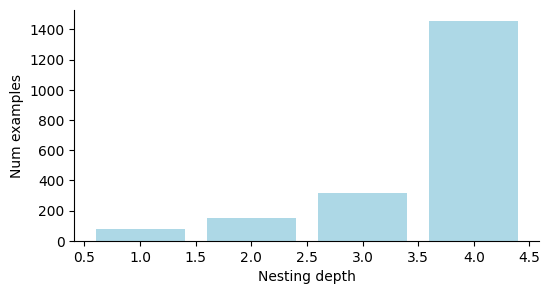

Length distribution: {2: 50, 4: 33, 6: 16, 8: 294, 10: 98, 12: 163, 14: 187, 16: 215, 18: 394, 20: 550}
Depth distribution: {1: 78, 2: 150, 3: 314, 4: 1458}


In [157]:
### Generate dataset
num_positive, num_negative = 2000, 2000
date = datetime.now(timezone).strftime("%m%d_%H%M%S")

max_depth = 4
max_length = 20 #100
min_length = 1
transition = (0.02, 0.5, 0.48)
metadata = {
    "date": date,
    "max_depth": max_depth,
    "max_length": max_length,
    "min_length": min_length,
    "transition": transition,
    "num_positive": num_positive,
    "num_negative": num_negative,
}
samples_pos, samples_neg = [], []
length_dist_pos, depth_dist_pos = Counter(), Counter()

### Generate positives
weights_max_depth_for_valid = [0, 0, 0, 80] #[10, 10, 20, 100]
for i in trange(num_positive):
    max_depth_this_time = random.choices(list(range(1, max_depth+1)), weights=weights_max_depth_for_valid, k=1)[0]
    s = generate(max_depth_this_time, 0, max_length, transition).replace('e', '')
    depth = double_check(s)
    while len(s) < min_length or len(s) > max_length or (not 0 < depth <= max_depth_this_time): # ensure min_length <= length <= max_length
        if depth == -1:
            print(f"False positive: {s}")
        elif depth > max_depth_this_time:
            print(f"Exceed max_depth: {s}")
        s = generate(max_depth_this_time, 0, max_length, transition).replace('e', '')
        depth = double_check(s)
        
    samples_pos.append(json.dumps({
        "length": len(s),
        "depth": depth,
        "sample": s,
        "label": True,
    }))
    length_dist_pos[len(s)] += 1
    depth_dist_pos[depth] += 1
length_dist_pos = dict(sorted(length_dist_pos.items(), key = lambda i: i[0]))
depth_dist_pos = dict(sorted(depth_dist_pos.items(), key = lambda i: i[0]))
make_barplot(length_dist_pos, 'Sequence length', 'Num examples')
make_barplot(depth_dist_pos, 'Nesting depth', 'Num examples')
print(f"Length distribution: {length_dist_pos}")
print(f"Depth distribution: {depth_dist_pos}")

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:00<00:00, 2057.76it/s]


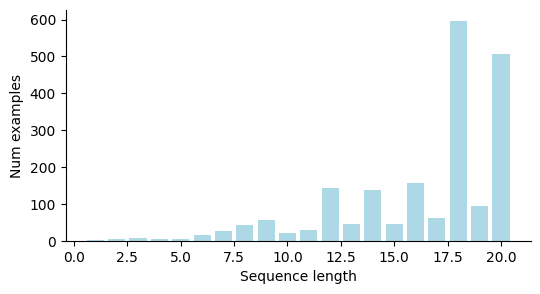

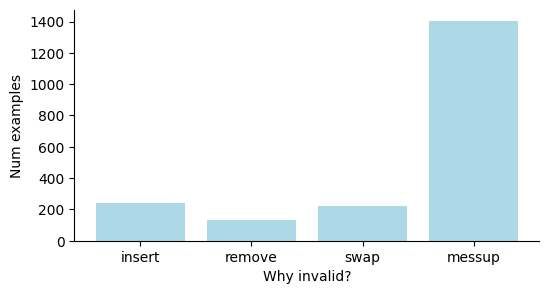

Length distribution: {1: 3, 2: 4, 3: 7, 4: 4, 5: 5, 6: 15, 7: 26, 8: 44, 9: 55, 10: 21, 11: 29, 12: 142, 13: 45, 14: 137, 15: 46, 16: 157, 17: 61, 18: 597, 19: 94, 20: 508}
Strategy distribution: {'insert': 239, 'remove': 132, 'swap': 224, 'messup': 1405}


In [158]:
### Generate negatives
transition_for_invalid = (0.02, 0.5, 0.48)
length_dist_neg, strategy_dist_neg = Counter(), Counter()
weights_for_invalid_strategy = [0.1, 0.1, 0.2, 0.6] # insert, remove, swap, messup
for i in trange(num_negative):
    s, strategy = generate_invalid(max_depth, 0, max_length, transition_for_invalid, weights_for_invalid_strategy)
    s = s.replace('e', '')
    depth = double_check(s)
    while len(s) < min_length or len(s) > max_length or depth != -1: 
        if depth != -1: print(f"False negative: {s}")
        s, strategy = generate_invalid(max_depth, 0, max_length, transition_for_invalid, weights_for_invalid_strategy)
        s = s.replace('e', '')
        depth = double_check(s)
        
    samples_neg.append(json.dumps({
        "length": len(s),
        "strategy": strategy,
        "sample": s,
        "label": False,
    }))
    length_dist_neg[len(s)] += 1
    strategy_dist_neg[strategy] += 1
length_dist_neg = dict(sorted(length_dist_neg.items(), key = lambda i: i[0]))
strategy_dist_neg = dict(sorted(strategy_dist_neg.items(), key = lambda i: ["insert", "remove", "swap", "messup"].index(i[0])))
make_barplot(length_dist_neg, 'Sequence length', 'Num examples')
make_barplot(strategy_dist_neg, 'Why invalid?', 'Num examples')
print(f"Length distribution: {length_dist_neg}")
print(f"Strategy distribution: {strategy_dist_neg}")

In [159]:
### Save dataset
metadata["weights_max_depth_for_valid"] = weights_max_depth_for_valid
metadata["transition_for_invalid"] = transition_for_invalid
metadata["weights_for_invalid_strategy"] = weights_for_invalid_strategy
metadata["length_dist_pos"] = length_dist_pos
metadata["depth_dist_pos"] = depth_dist_pos
metadata["length_dist_neg"] = length_dist_neg
metadata["strategy_dist_neg"] = strategy_dist_neg

save_dir = f"../data/{date}"
os.makedirs(save_dir, exist_ok=True)
with open(os.path.join(save_dir, "data.json"), "w") as f:
    json.dump({
        "metadata": metadata,
        "positive": samples_pos,
        "negative": samples_neg,
    }, f, indent=4)

### write data to txt
rows = []
for datum in samples_pos + samples_neg:
    x = json.loads(datum)
    rows.append((x['sample'], x['label']))
rows.sort(key=lambda x: len(x[0]))
with open(os.path.join(save_dir, f"dyck1-{max_depth}.txt"), "w") as f:
    for sample, label in rows:
        f.write(f"{sample}:{str(label)}\n")

In [87]:
max_depth = 4
max_length = 100
transition = (0.05, 0.45, 0.5)
valid = generate(max_depth, 0, max_length, transition)
print(valid, len(valid), double_check(valid))
invalid, strategy = generate_invalid(max_depth, 0, max_length, transition)
print(invalid, len(invalid), strategy, double_check(invalid))


(((()()()()()()()()()()()))) 28 4
(((()))))(((()()))()()()()((()))((()))(()()()(()())))(((()))())((()()()()())(((()))()()()(()())) 96 messup -1


(()()()()())(((())))(()()()()()())(((())))((()()())()()()()(())()()(())()()((())) 

## Draft

In [46]:
import signal
def timeout_handler(signum, frame):
    raise TimeoutError("Code block execution exceeded time limit")
signal.signal(signal.SIGALRM, timeout_handler)
signal.alarm(5)
try:
    transition = (0.05, 0.45, 0.5)
    seq = generate(4, 0, 100, transition)
    print(seq, len(seq))
except TimeoutError as e:
    print(e)
finally:
    signal.alarm(0) # Disable the alarm after execution or error

(((())))((()())()(()()()(())))(((()())()()()()()()(())(()()))) 62
